# 프로젝트 관련 내용

| 번호 | 테이블명             | 테이블 설명                   | 주요 컬럼                                               |
|------|----------------------|-------------------------------|----------------------------------------------------------|
| 1    | trial_register       | 3일체험 신청                  | 유저id, 3일체험신청일시                                  |
| 2    | trial_visit_info     | 3일체험 신청자 일자별 방문기록 | 유저id, 날짜, 지점id, 최초입실시각, 최종퇴실시각, 체류시간 |
| 3    | trial_access_log     | 3일체험 신청자 출입기록        | 유저id, 지점id, timestamp, 출입방향                      |
| 4    | trial_payment        | 3일체험 신청자 결제 여부       | 유저id, 결제여부                                         |
| 5    | site_area            | 지점별 면적                   | 지점id, 지점 면적                                        |


이번 데이터에서는 다음과 같은 오류값들이 존재합니다. 팀원 분들과 충분히 논의한 뒤 합리적이라고 생각하는 방식대로 오류값들을 처리해주세요. (추가로 발견했다면 그 점에 대해 언급해주셔도 좋아요.)
| 테이블             | 이상치 내용                                                                                                                                     | 이상치 원인                                                                                                                                                        |
|------------------|----------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| trial_register    | 1) 같은 날 2회 3일 체험을 신청한 경우<br>2) 서로 다른 날 2회 3일 체험을 신청한 경우                                                            | 1) 전산 오류로 인해 현장 매니저가 임시로 권한 부여한 케이스<br>2) 체험 신청 후 방문하지 못해 재신청한 케이스                                                       |
| trial_visit_info  | 1) `stay_time`은 결측치가 없는데 `first_enter_time` 또는 `last_leave_time`이 결측치인 경우<br>2) `stay_time`과 입·퇴실 시각이 일치하지 않는 경우 | 1) 분 단위 출입으로 인해 기록 누락 가능<br>2) 중간 퇴실/재입실로 인해 `stay_time`이 `first_enter_time`~`last_leave_time` 구간과 일치하지 않을 수 있음              |


이상치 처리 이원찬 개인적인 전처리 의견

trial_register 내용

- 같은 날 2회 3일 체험을 신청한 경우
- 서로 다른 날 2회 3일 체험을 신청한 경우
    - `drop_duplicates()` 를 적용한 뒤 `keep=first` 값으로 유지 (최초 체험은 첫 번째 순서를 부여)

trial_visit_info 내용

- `stay_time` 은 결측치가 없는데 first_enter_time 또는 last_leave_time이 결측치인 경우
- `stay_time` 과 입/퇴실 시각이 일치하지 않는 경우
    - `stay_time` 은 입/퇴실의 파생 변수로 인식
    - 머신 러닝을 진행할 시 입/퇴실 시각 컬럼은 삭제 
    - 혹은 이용 시간대가 아침/점심/저녁/야간 인지 분류하는 period 값을 새로 추가 → 이는 입/퇴실 시간이 모두 존재하는 데이터만 보존하고 나머지는 drop 처리

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

import os
import glob

from scipy.stats import pointbiserialr

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from kneed import KneeLocator as kl

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from IPython.display import clear_output

In [2]:
output = glob.glob('./data/*.csv')  # 경로에 맞게 지정
for file_path in output:
    file_name = os.path.basename(file_path).replace('.csv', '')
    df = pd.read_csv(file_path)

    globals()[file_name] = df

In [3]:
df_lst = [trial_register, trial_visit_info, trial_access_log, trial_payment, site_area]

for df in df_lst:
    display(df.head(5))

,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594


,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 07:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-06 15:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 14:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
3,1716588,1,2023-07-06 13:09:48.758097,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
4,1719649,1,2023-07-07 10:12:42.083352,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3
3,0,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,0,1d49ba36-6c23-405b-9514-aa7f4aeceff0


,site_id,area_pyeong
0,1,50
1,2,100
2,3,150
3,4,100
4,5,150


In [4]:
def basic_information(df):
    print(f'data shape : {df.shape}')
    
    basic_info_df = pd.DataFrame(data=df.dtypes, columns=['dtypes'])
    basic_info_df['missing'] = df.isnull().sum().values
    basic_info_df['missing_rate (%)'] = df.isnull().sum().values / len(df) * 100
    basic_info_df['nunique'] = df.nunique().values

    # describe 통계량 (수치형/범주형 포함)
    desc_df = df.describe(include='all').transpose()

    # 수치형 항목만 해당되는 통계량 추가
    for col in ['mean', 'std', 'min','25%', '50%', '75%', 'max']:
        if col in desc_df.columns:
            basic_info_df[col] = desc_df[col]

    # 최빈값 및 해당 최빈값의 count
    basic_info_df['mode'] = {col: df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else None for col in df.columns}
    basic_info_df['mode_counts'] = {col: df[col].value_counts().max() if not df[col].value_counts().empty else 0 for col in df.columns}

    return basic_info_df

In [5]:
for df in df_lst:
    display(basic_information(df))

data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mode,mode_counts
trial_date,object,0,0.0,855,2022-12-08,144
user_uuid,object,0,0.0,9624,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (11477, 7)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
site_id,int64,0,0.000000,9,7.502832,11.60872,1.0,2.0,4.0,6.0,49.0,3,2370
date,object,0,0.000000,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-09,57
stay_time,object,0,0.000000,11429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:20:17.062840,2
stay_time_second,int64,0,0.000000,9725,16689.460922,11968.841154,1.0,7776.0,14699.0,23326.0,86377.0,3448,5
first_enter_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-06-09 00:00:00,6
last_leave_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-06-08 23:59:59,6
user_uuid,object,0,0.000000,6534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,039fa563-fc65-4b0c-9087-4beb5cd17fd7,8


data shape : (63708, 5)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
id,int64,0,0.0,63349,999112.370676,681178.05588,51548.0,338911.25,931246.0,1623064.75,2193657.0,1238281,2
checkin,int64,0,0.0,2,1.495448,0.499983,1.0,1.0,1.0,2.0,2.0,1,32144
cdate,object,0,0.0,63349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-20 00:40:40.547291,2
site_id,int64,0,0.0,9,7.290843,11.116908,1.0,3.0,4.0,6.0,49.0,3,17125
user_uuid,object,0,0.0,6026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,948ae0cc-bc5a-4bd3-89ce-92b2a5c34710,126


data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
is_payment,int64,0,0.0,2,0.379335,0.485247,0.0,0.0,0.0,1.0,1.0,0,5995
user_uuid,object,0,0.0,9624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (9, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
site_id,int64,0,0.0,9,14.888889,19.348414,1.0,3.0,5.0,17.0,49.0,1,1
area_pyeong,int64,0,0.0,3,94.444444,46.398036,50.0,50.0,100.0,150.0,150.0,50,4


In [6]:
trial_register.duplicated(subset=['user_uuid']).sum()

np.int64(35)

In [7]:
trial_register = trial_register.drop_duplicates(subset=['user_uuid'], keep='first')

In [8]:
df_lst = [trial_register, trial_visit_info, trial_access_log, trial_payment, site_area]

for df in df_lst:
    display(basic_information(df))

data shape : (9624, 2)


,dtypes,missing,missing_rate (%),nunique,mode,mode_counts
trial_date,object,0,0.0,855,2022-12-08,144
user_uuid,object,0,0.0,9624,000590dc-046f-462b-8225-4c81a97b7166,1


data shape : (11477, 7)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
site_id,int64,0,0.000000,9,7.502832,11.60872,1.0,2.0,4.0,6.0,49.0,3,2370
date,object,0,0.000000,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-09,57
stay_time,object,0,0.000000,11429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:20:17.062840,2
stay_time_second,int64,0,0.000000,9725,16689.460922,11968.841154,1.0,7776.0,14699.0,23326.0,86377.0,3448,5
first_enter_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-06-09 00:00:00,6
last_leave_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-06-08 23:59:59,6
user_uuid,object,0,0.000000,6534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,039fa563-fc65-4b0c-9087-4beb5cd17fd7,8


data shape : (63708, 5)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
id,int64,0,0.0,63349,999112.370676,681178.05588,51548.0,338911.25,931246.0,1623064.75,2193657.0,1238281,2
checkin,int64,0,0.0,2,1.495448,0.499983,1.0,1.0,1.0,2.0,2.0,1,32144
cdate,object,0,0.0,63349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-20 00:40:40.547291,2
site_id,int64,0,0.0,9,7.290843,11.116908,1.0,3.0,4.0,6.0,49.0,3,17125
user_uuid,object,0,0.0,6026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,948ae0cc-bc5a-4bd3-89ce-92b2a5c34710,126


data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
is_payment,int64,0,0.0,2,0.379335,0.485247,0.0,0.0,0.0,1.0,1.0,0,5995
user_uuid,object,0,0.0,9624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (9, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
site_id,int64,0,0.0,9,14.888889,19.348414,1.0,3.0,5.0,17.0,49.0,1,1
area_pyeong,int64,0,0.0,3,94.444444,46.398036,50.0,50.0,100.0,150.0,150.0,50,4


## 결측치 채우기 방안

In [9]:
# trial_visit_info에 결측치를 발생하는 인원을 리스트
isnull_user_uuid = trial_visit_info[trial_visit_info.isnull().any(axis=1)]['user_uuid'].unique()

# 모든 데이터에서 isnull_user_uuid 리스트
trial_access_log[trial_access_log['user_uuid'].isin(isnull_user_uuid)]['user_uuid'].value_counts().head(30)

user_uuid
4622f625-f93d-4f65-9e9a-e7b24171da62    72
7ee3d40f-b2b3-4c1e-8f5b-fedfe77a28e0    47
2965514a-3b8c-497a-a797-ad5b320e0b41    44
05a9cf4a-ceaf-4396-ac13-7db53c1ca393    36
5355f73c-1bc7-4bca-82aa-80857e2656b8    35
c8be2353-f4ae-4dda-8f93-e5cb4d72ec19    34
fe2c2ec8-c4b5-485b-ba3c-1d2cbdfb6a6d    33
9e16fb62-bfb0-43ce-9ef8-892f9d7280d2    32
47a17261-1682-45ce-b665-2d19b92601ce    31
3ea29b0e-572a-4d54-b8e1-add541f38a13    30
760f859b-e8d6-4819-8aa1-624b0352b6bd    29
ab3856b5-d5ce-42a0-80a0-1d5600ab666b    29
e4b84a3e-dc6b-4e17-9ab8-108119fc482c    28
c4c93667-13e5-47d1-abd9-63d5ac824149    28
4a0f3b44-5c65-402e-8d1e-5d91e52ff0ca    27
12e1413c-9d4d-4990-b710-b1373b72b004    26
84391811-2762-4d49-98b8-2a68b1058649    26
7b4867e0-23e5-4fe1-a2f0-f9e8ba605e7a    25
2f50b976-558d-461b-a520-dbc6c7ea41b3    25
381873f9-bd14-4832-84b9-e94c5b172bc8    24
a46357f4-4d19-43cf-afa4-5b5275a9f571    24
953a48a9-1292-4353-ad72-5c99dd47ae28    24
dc7c384c-355d-4087-8cb8-bae8b764c195    23
c

In [10]:
# output = glob.glob('./data/*.csv')
# for file_path in output:
#     file_name = os.path.basename(file_path).replace('.csv', '')
#     df = pd.read_csv(file_path)
    
#     globals()[file_name] = df
#     display(file_name)

# # access Dataset의 Cdate의 ms 단위 제거 후 Datetime으로 형변환
# trial_access_log['cdate'] = trial_access_log['cdate'].str.split('.').str[0]
# trial_access_log['cdate'] = pd.to_datetime(trial_access_log['cdate'])

# trial_access_log['kdate'] = trial_access_log['cdate'] + pd.Timedelta(hours=9)

# null_access_log = trial_visit_info[trial_visit_info['first_enter_time'].isna()]['user_uuid'].unique()

# def fill_date(arg):

#     trial_access_log['kdate'] = pd.to_datetime(trial_access_log['kdate'], errors='coerce')
#     trial_visit_info['date'] = pd.to_datetime(trial_visit_info['date'], errors='coerce')
    
#     tt = trial_access_log[trial_access_log['user_uuid'] == arg].sort_values('kdate')['kdate'].dt.to_period('D').unique()
    
#     for i in tt:
#         fillna_lst = trial_access_log[
#             (trial_access_log['user_uuid'] == arg) & 
#             (trial_access_log['kdate'].dt.to_period('D') == i)
#         ]['kdate'].sort_values()
        
#         if not fillna_lst.empty:
#             condition = (
#                 (trial_visit_info['user_uuid'] == arg) & 
#                 (trial_visit_info['date'].dt.to_period('D') == i)
#             )
#             trial_visit_info.loc[condition, 'first_enter_time'] = fillna_lst.iloc[0]
#             trial_visit_info.loc[condition, 'last_leave_time'] = fillna_lst.iloc[-1]
            
# for item in null_access_log:
#     fill_date(item)

In [11]:
# trial_visit_info.isnull().sum()

In [12]:
trial_access_log['cdate'] = pd.to_datetime(trial_access_log['cdate'], errors='coerce')
trial_visit_info['date'] = pd.to_datetime(trial_visit_info['date'], errors='coerce')

trial_access_log['cdate'] = trial_access_log['cdate'] + pd.Timedelta(hours=9)

In [13]:
null_access_log = trial_visit_info[trial_visit_info['first_enter_time'].isna()]['user_uuid'].unique()

def fill_date(arg):
    
    tt = trial_access_log[trial_access_log['user_uuid'] == arg].sort_values('cdate')['cdate'].dt.to_period('D').unique()
    
    for i in tt:
        fillna_lst = trial_access_log[
            (trial_access_log['user_uuid'] == arg) & 
            (trial_access_log['cdate'].dt.to_period('D') == i)
        ]['cdate'].sort_values()
        
        if not fillna_lst.empty:
            condition = (
                (trial_visit_info['user_uuid'] == arg) & 
                (trial_visit_info['date'].dt.to_period('D') == i)
            )
            trial_visit_info.loc[condition, 'first_enter_time'] = fillna_lst.iloc[0]
            trial_visit_info.loc[condition, 'last_leave_time'] = fillna_lst.iloc[-1]
            
for item in null_access_log:
    fill_date(item)

In [14]:
trial_visit_info.isnull().sum()

site_id              0
date                 0
stay_time            0
stay_time_second     0
first_enter_time    65
last_leave_time     65
user_uuid            0
dtype: int64

In [15]:
# 원본 데이터에서도 실제 사용 시간과 first_enter_time, last_leave_time 간의 차이는 최대 30분 차이가 발생
# 결측치를 채운 내용도 이와 같은 기준을 두어 최대 30분 차이 이상 나는 데이터는 이상치로 판단하고 제거 처리리

# 결측치를 채웠음에도 불구하고 access_log 내의 데이터 내용이 존재하지 않아 발생한 결측치가 발생한 유저의 unique
always_isnull_user_uid = trial_visit_info[trial_visit_info.isnull().any(axis=1)]['user_uuid'].unique()

# access_log에 출입 데이터가 남아있어 결측치를 채웠지만 실제 사용 시간과의 차가 30분 이상인 유저의 unique
more_than_30min_user_uid = trial_visit_info[
    (trial_visit_info['stay_time_second'] - (
        pd.to_datetime(trial_visit_info['last_leave_time'], format='mixed') -
        pd.to_datetime(trial_visit_info['first_enter_time'], format='mixed')
    ).dt.total_seconds()) / 1800 > 1
]['user_uuid'].unique()

# 이 유저 리스트들을 한 리스트로 이어 붙이기
# 리스트 언팩킹을 통해 데이터 이어 붙이기기
remove_user_uuid = [*always_isnull_user_uid, *more_than_30min_user_uid]

# 합친 데이터의 크기 확인
len(remove_user_uuid)

# 데이터 전체 리스트화화
df_lst = [trial_register, trial_visit_info, trial_access_log, trial_payment, site_area]

# 이름과 df를 매핑해주는 딕셔너리로 관리
df_dict = {
    'trial_register': trial_register,
    'trial_visit_info': trial_visit_info,
    'trial_access_log': trial_access_log,
    'trial_payment': trial_payment,
    'site_area': site_area,
}

for name, df in df_dict.items():
    if 'user_uuid' in df.columns:
        df = df[~df['user_uuid'].isin(remove_user_uuid)]
        df_dict[name] = df  # 갱신

        # 데이터 출력
        print(f"\n🧾 {name}.csv 데이터:")
        display(df)
        display(basic_information(df))

        # CSV 저장
        df.to_csv(f"{name}.csv", index=False)


🧾 trial_register.csv 데이터:


,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0
...,...,...
9654,2023-11-17,d7599df4-1e5a-4f5e-97ce-c42047bfd87c
9655,2023-11-17,43263092-3b28-4817-9fa9-4205ad3097fe
9656,2023-11-17,51a40f33-1027-4544-9b95-45bca7c104fb
9657,2023-11-18,3e649531-bf5b-4b99-84e5-ca3e0e647d0c


data shape : (9522, 2)


,dtypes,missing,missing_rate (%),nunique,mode,mode_counts
trial_date,object,0,0.0,854,2022-12-08,144
user_uuid,object,0,0.0,9522,000590dc-046f-462b-8225-4c81a97b7166,1



🧾 trial_visit_info.csv 데이터:


...

,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
id,int64,0,0.0,62487,1011734.603173,677193.353844,51548.0,356769.25,947892.5,1629578.5,2193657.0,1238281,2
checkin,int64,0,0.0,2,1.49537,0.499983,1.0,1.0,1.0,2.0,2.0,1,31714
cdate,datetime64[ns],0,0.0,62487,2022-09-16 03:04:20.215699712,NaN,2021-05-02 18:42:13.893455,2021-12-27 12:59:54.191234304,2022-09-13 17:34:41.879042560,2023-06-03 17:36:52.286330624,2024-01-01 23:36:13.987243,2023-01-20 09:40:40.547291,2
site_id,int64,0,0.0,9,7.352322,11.179678,1.0,3.0,4.0,6.0,49.0,3,16852
user_uuid,object,0,0.0,5943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,948ae0cc-bc5a-4bd3-89ce-92b2a5c34710,126



🧾 trial_payment.csv 데이터:


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3
3,0,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,0,1d49ba36-6c23-405b-9514-aa7f4aeceff0
...,...,...
9654,0,d7599df4-1e5a-4f5e-97ce-c42047bfd87c
9655,0,43263092-3b28-4817-9fa9-4205ad3097fe
9656,0,51a40f33-1027-4544-9b95-45bca7c104fb
9657,0,3e649531-bf5b-4b99-84e5-ca3e0e647d0c


data shape : (9557, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
is_payment,int64,0,0.0,2,0.377315,0.48474,0.0,0.0,0.0,1.0,1.0,0,5951
user_uuid,object,0,0.0,9522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02458b10-7f2b-4030-950b-ba650ce2fb49,2


## 각 공유 오피스의 면적과 이용 횟수와의 상관관계 (피어슨 상관계수)

In [16]:
trial_visit_info_dropna = trial_visit_info.dropna()

trial_visit_info_groupby = trial_visit_info_dropna.groupby(['site_id']).size().reset_index(name='count')

display(trial_visit_info_groupby)

,site_id,count
0,1,1370
1,2,1964
2,3,2349
3,4,847
4,5,1055
5,6,2233
6,17,797
7,47,534
8,49,263


In [17]:
corr_df = pd.merge(
    site_area,
    trial_visit_info_groupby,
    how='left',
    on='site_id'
)

corr_df.drop(labels=['site_id'], axis=1, inplace=True)
corr_df.dropna(inplace=True)
corr_df = corr_df.corr()

display(corr_df)

,area_pyeong,count
area_pyeong,1.000000,0.701016
count,0.701016,1.000000


## 공유 오피스 입장 시간대에 따른 그래프 시각화

In [18]:
trial_visit_info_dropna['first_enter_time'] = pd.to_datetime(trial_visit_info_dropna['first_enter_time'], errors='coerce')
trial_visit_info_dropna['year'] = trial_visit_info_dropna['first_enter_time'].dt.year
trial_visit_info_dropna['month'] = trial_visit_info_dropna['first_enter_time'].dt.month
trial_visit_info_dropna['day'] = trial_visit_info_dropna['first_enter_time'].dt.day
trial_visit_info_dropna['hour'] = trial_visit_info_dropna['first_enter_time'].dt.hour
trial_visit_info_dropna['minute'] = trial_visit_info_dropna['first_enter_time'].dt.minute

C:\Users\lento\AppData\Local\Temp\ipykernel_10520\402268404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_visit_info_dropna['first_enter_time'] = pd.to_datetime(trial_visit_info_dropna['first_enter_time'], errors='coerce')
C:\Users\lento\AppData\Local\Temp\ipykernel_10520\402268404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_visit_info_dropna['year'] = trial_visit_info_dropna['first_enter_time'].dt.year
C:\Users\lento\AppData\Local\Temp\ipykernel_10520\402268404.py:3: SettingWithCo

In [19]:
display(trial_visit_info_dropna.head(5))

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid,year,month,day,hour,minute
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,23.0,16.0,11.0
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,24.0,16.0,10.0
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,25.0,10.0,19.0
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594,2023.0,12.0,23.0,14.0,49.0
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594,2023.0,12.0,26.0,14.0,57.0


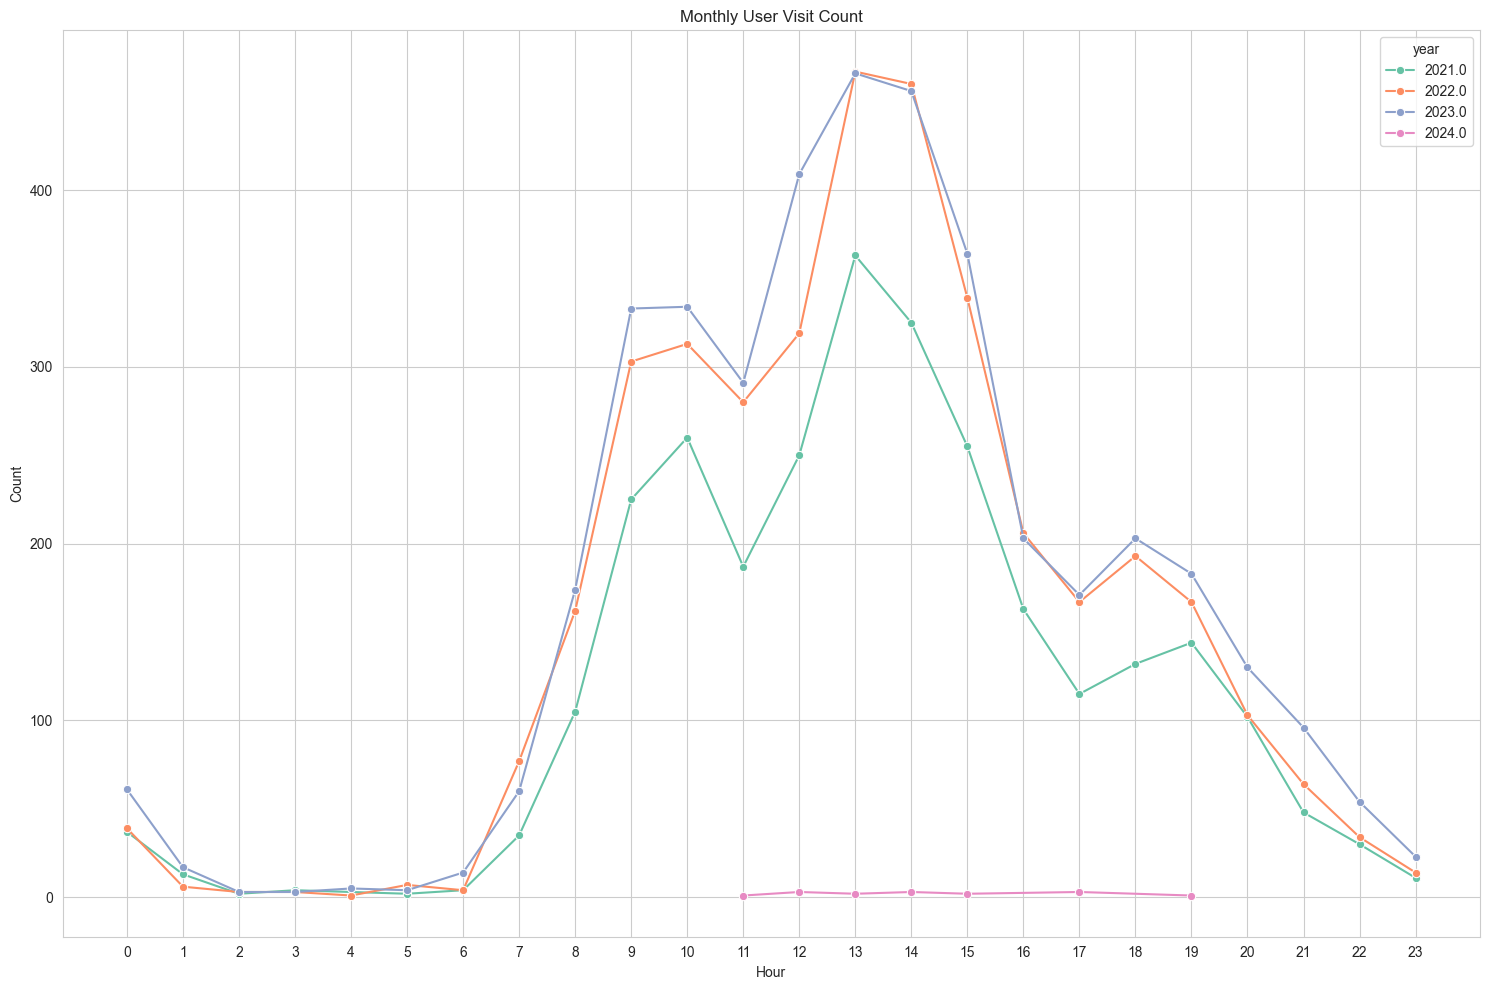

In [20]:
month_groupby_df = trial_visit_info_dropna.groupby(['year', 'hour']).size().reset_index(name='count')

plt.figure(figsize=(15, 10))
sns.set_style('whitegrid')
sns.lineplot(data=month_groupby_df, x='hour', y='count', hue='year', marker='o', palette='Set2')
plt.title('Monthly User Visit Count')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.xticks(month_groupby_df['hour'].unique())
plt.grid(True)
plt.tight_layout()
plt.show()

## point-biserialr 을 통한 방문한 오피스 수와 방문 횟수에 따른 is_payment 검정

In [21]:
# 지점 방문한 오피스 수와 방문횟수 groupby
trial_visit_info_groupby = trial_visit_info.groupby('user_uuid').agg(
    office_count = ('site_id', lambda x: set(list(x))),
    visit_count = ('first_enter_time', 'count')
).reset_index()

# office_count를 방문한 오피스의 수로 변환환
trial_visit_info_groupby['office_count'] = trial_visit_info_groupby['office_count'].apply(lambda x: len(x))

# 결제 여부 merge
trial_visit_info_merge = trial_visit_info_groupby.merge(
    trial_payment,
    how='left',
    on='user_uuid'
)

# 만약 결측치가 있을 경우 dropna
trial_visit_info_merge.dropna(inplace=True)

# 데이터 확인
display(trial_visit_info_merge)

# pointbiserialr 검정
# 필요한 컬럼만 추출해서 결측치 제거
df_corr = trial_visit_info_merge[['is_payment', 'office_count', 'visit_count']].dropna()

# office_count와 is_payment 간 상관관계
corr_office, pval_office = pointbiserialr(df_corr['is_payment'], df_corr['office_count'])

# visit_count와 is_payment 간 상관관계
corr_visit, pval_visit = pointbiserialr(df_corr['is_payment'], df_corr['visit_count'])

# 결과 출력
print(f"[office_count] Point Biserial Corr: {corr_office:.4f}, p-value: {pval_office:.4f}")
print(f"[visit_count] Point Biserial Corr: {corr_visit:.4f}, p-value: {pval_visit:.4f}")

,user_uuid,office_count,visit_count,is_payment
0,000590dc-046f-462b-8225-4c81a97b7166,1,1,0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,1,3,1
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,1,2,0
3,002606d9-38ca-48f3-910c-cbfada9a9109,1,2,0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,1,2,1
...,...,...,...,...
6556,ffc79669-ed11-4cde-86d4-8ec232ac7b14,1,1,0
6557,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,1,2,0
6558,ffce32ca-2efc-4485-b685-4b65811c2dcf,1,1,0
6559,ffd287bc-2797-4788-82fa-6268c82e7fa9,1,3,0


[office_count] Point Biserial Corr: 0.0352, p-value: 0.0043
[visit_count] Point Biserial Corr: 0.1255, p-value: 0.0000


## 체류 시간 히스토그램

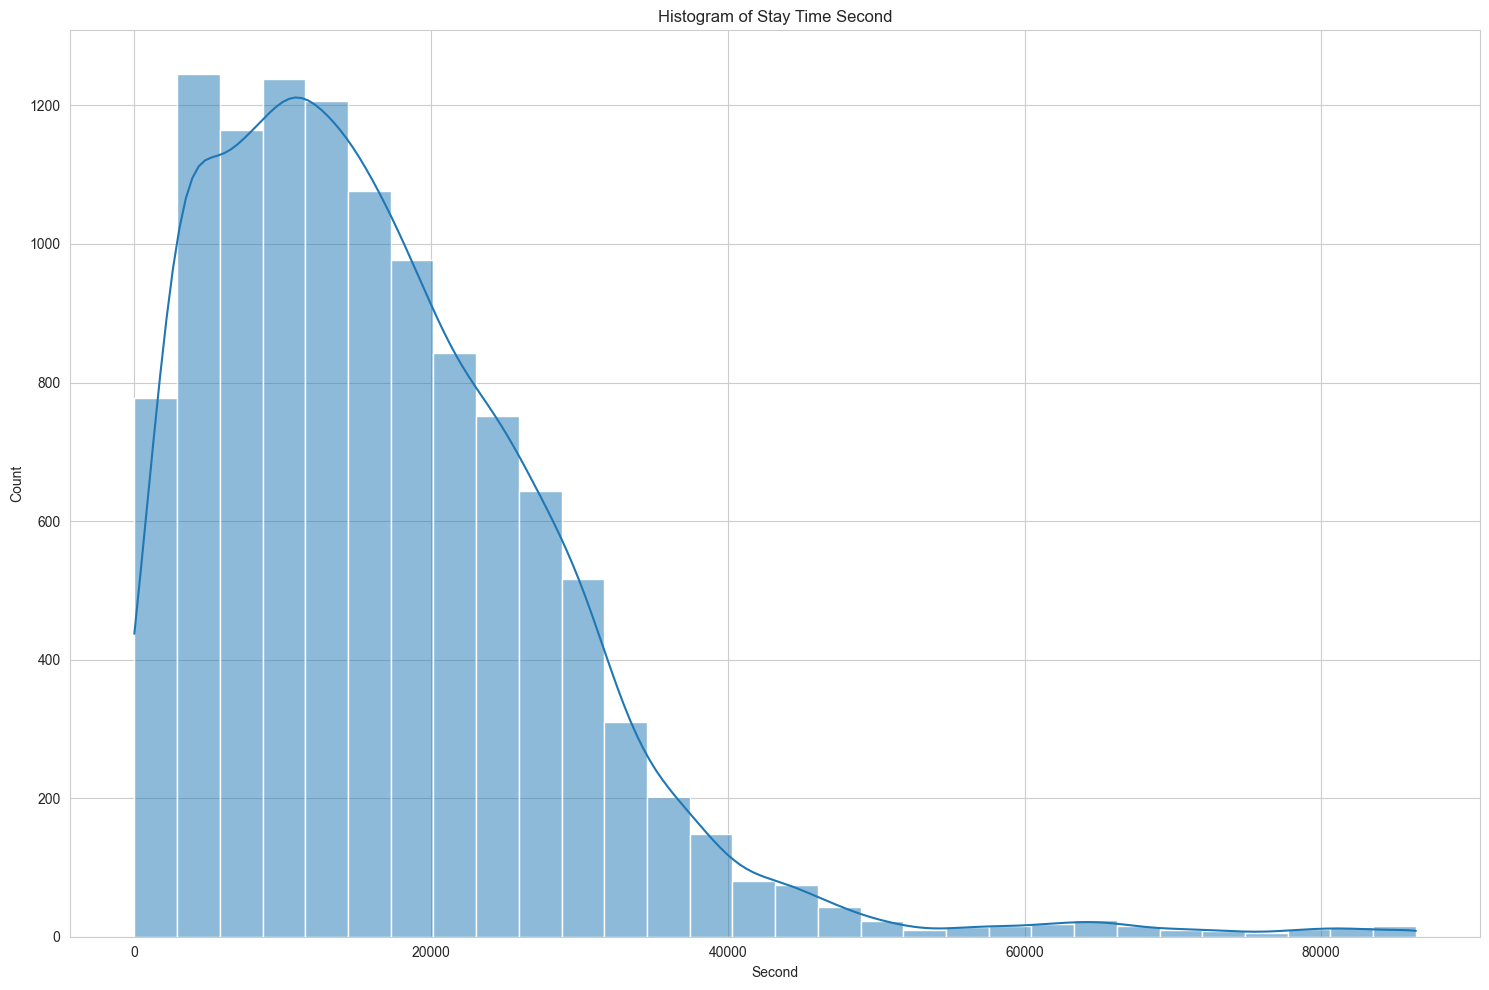

In [22]:
plt.figure(figsize=(15,10))
sns.histplot(data=trial_visit_info['stay_time_second'], bins=30, kde=True)
plt.title('Histogram of Stay Time Second')
plt.xlabel('Second')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 비지도 학습

In [23]:
# visit_info에서 평균 체류한 시간과 방문한 오피스의 수와 총 방문 횟수를 위한 groupby
trial_visit_info_groupby_v2 = trial_visit_info.groupby('user_uuid').agg(
    avg_stay_time_second = ('stay_time_second', 'mean'),
    office_count = ('site_id', lambda x: len(set(list(x)))),
    visit_count = ('first_enter_time', 'count')
).reset_index()

# 데이터 확인
display(trial_visit_info_groupby_v2)

# access_log에서 평균적으로 하루에 얼마나 checkin하고 checkout하는지에 대한 groupby
trial_access_log['cdate_period'] = trial_access_log['cdate'].dt.to_period('D')

trial_access_log_groupby = trial_access_log.groupby(['user_uuid', 'cdate_period']).agg(
    checkin_count = ('checkin', lambda x: (x == 1).sum()),
    checkout_count = ('checkin', lambda x: (x == 2).sum())
).reset_index()

trial_access_log_groupby_v2 = trial_access_log_groupby.groupby('user_uuid').agg(
    avg_checkin_count = ('checkin_count', 'mean'),
    avg_checkout_count = ('checkout_count', 'mean')
).reset_index()

# 데이터 확인
display(trial_access_log_groupby_v2)

# groupby한 데이터들을 merge 처리
groupby_merge_df = pd.merge(
    trial_visit_info_groupby_v2,
    trial_access_log_groupby_v2,
    how='inner',
    on='user_uuid'
)

# 데이터 확인
display(groupby_merge_df)

,user_uuid,avg_stay_time_second,office_count,visit_count
0,000590dc-046f-462b-8225-4c81a97b7166,21417.000000,1,1
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,15189.666667,1,3
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,38686.000000,1,2
3,002606d9-38ca-48f3-910c-cbfada9a9109,12512.000000,1,2
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,11804.500000,1,2
...,...,...,...,...
6529,ffc79669-ed11-4cde-86d4-8ec232ac7b14,17292.500000,1,1
6530,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,14806.500000,1,2
6531,ffce32ca-2efc-4485-b685-4b65811c2dcf,8450.000000,1,1
6532,ffd287bc-2797-4788-82fa-6268c82e7fa9,17618.333333,1,3


,user_uuid,avg_checkin_count,avg_checkout_count
0,000590dc-046f-462b-8225-4c81a97b7166,3.0,3.0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,4.5,4.5
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,5.5,4.0
3,002606d9-38ca-48f3-910c-cbfada9a9109,2.0,2.0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,5.0,5.0
...,...,...,...
6021,ffc79669-ed11-4cde-86d4-8ec232ac7b14,5.0,4.0
6022,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,2.5,2.5
6023,ffce32ca-2efc-4485-b685-4b65811c2dcf,2.0,2.0
6024,ffd287bc-2797-4788-82fa-6268c82e7fa9,5.0,5.0


,user_uuid,avg_stay_time_second,office_count,visit_count,avg_checkin_count,avg_checkout_count
0,000590dc-046f-462b-8225-4c81a97b7166,21417.000000,1,1,3.0,3.0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,15189.666667,1,3,4.5,4.5
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,38686.000000,1,2,5.5,4.0
3,002606d9-38ca-48f3-910c-cbfada9a9109,12512.000000,1,2,2.0,2.0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,11804.500000,1,2,5.0,5.0
...,...,...,...,...,...,...
6018,ffc79669-ed11-4cde-86d4-8ec232ac7b14,17292.500000,1,1,5.0,4.0
6019,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,14806.500000,1,2,2.5,2.5
6020,ffce32ca-2efc-4485-b685-4b65811c2dcf,8450.000000,1,1,2.0,2.0
6021,ffd287bc-2797-4788-82fa-6268c82e7fa9,17618.333333,1,3,5.0,5.0


In [24]:
trial_visit_info = df_lst[1].copy()
trial_access_log = df_lst[2].copy()

# 시간대, 요일 컬럼 추가
trial_access_log['cdate'] = pd.to_datetime(trial_access_log['cdate'])
trial_access_log['hour'] = trial_access_log['cdate'].dt.hour
trial_access_log['weekday'] = trial_access_log['cdate'].dt.weekday

# visit_info에서 평균 체류한 시간과 방문한 오피스의 수와 총 방문 횟수를 위한 groupby
trial_visit_info_groupby_v2 = trial_visit_info.groupby('user_uuid').agg(
    avg_stay_time_second = ('stay_time_second', 'mean'),
    office_count = ('site_id', lambda x: len(set(list(x)))),
    visit_count = ('first_enter_time', 'count')
).reset_index()

# 데이터 확인
# display(trial_visit_info_groupby_v2)

# access_log에서 평균적으로 하루에 얼마나 checkin하고 checkout하는지에 대한 groupby
trial_access_log['cdate_period'] = trial_access_log['cdate'].dt.to_period('D')

trial_access_log_groupby = trial_access_log.groupby(['user_uuid', 'cdate_period']).agg(
    checkin_count = ('checkin', lambda x: (x == 1).sum()),
    checkout_count = ('checkin', lambda x: (x == 2).sum())
).reset_index()

trial_access_log_groupby_v2 = trial_access_log_groupby.groupby('user_uuid').agg(
    avg_checkin_count = ('checkin_count', 'mean'),
    avg_checkout_count = ('checkout_count', 'mean')
).reset_index()

# 데이터 확인
# display(trial_access_log_groupby_v2)

# 방문한 지점수
trial_access_log_site = trial_access_log[['user_uuid', 'site_id', 'hour', 'weekday']].groupby(['user_uuid', 'site_id']).count().reset_index()

# groupby한 데이터들을 merge 처리
groupby_merge_df = pd.merge(
    trial_visit_info_groupby_v2,
    trial_access_log_groupby_v2,
    how='inner',
    on='user_uuid'
)

groupby_merge_df = pd.merge(
    groupby_merge_df,
    trial_access_log_site,
    how='inner',
    on='user_uuid'
)

# 데이터 확인
display(groupby_merge_df)

,user_uuid,avg_stay_time_second,office_count,visit_count,avg_checkin_count,avg_checkout_count,site_id,hour,weekday
0,000590dc-046f-462b-8225-4c81a97b7166,21417.000000,1,1,3.0,3.0,6,6,6
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,15189.666667,1,3,4.5,4.5,3,18,18
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,38686.000000,1,2,5.5,4.0,6,19,19
3,002606d9-38ca-48f3-910c-cbfada9a9109,12512.000000,1,2,2.0,2.0,17,8,8
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,11804.500000,1,2,5.0,5.0,5,10,10
...,...,...,...,...,...,...,...,...,...
6261,ffc79669-ed11-4cde-86d4-8ec232ac7b14,17292.500000,1,1,5.0,4.0,1,9,9
6262,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,14806.500000,1,2,2.5,2.5,2,10,10
6263,ffce32ca-2efc-4485-b685-4b65811c2dcf,8450.000000,1,1,2.0,2.0,4,4,4
6264,ffd287bc-2797-4788-82fa-6268c82e7fa9,17618.333333,1,3,5.0,5.0,6,20,20


In [25]:
display(basic_information(groupby_merge_df))

data shape : (6266, 9)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
user_uuid,object,0,0.0,6023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3b371ed1-3ef5-450d-ba29-b4e71fdc1bc4,4
avg_stay_time_second,float64,0,0.0,5747,16039.613701,10426.518652,9.0,8382.25,14627.0,21781.5,83865.0,2548.5,4
office_count,int64,0,0.0,4,1.104373,0.36611,1.0,1.0,1.0,1.0,4.0,1,5728
visit_count,int64,0,0.0,7,1.85142,0.883716,1.0,1.0,2.0,2.0,8.0,1,2691
avg_checkin_count,float64,0,0.0,62,3.445393,2.365583,0.0,2.0,3.0,4.666667,26.0,1.0,1176
avg_checkout_count,float64,0,0.0,59,3.382434,2.334726,0.0,2.0,3.0,4.5,20.666667,1.0,1198
site_id,int64,0,0.0,9,7.456751,11.556743,1.0,2.0,3.0,6.0,49.0,3,1269
hour,int64,0,0.0,67,10.162624,9.111049,1.0,4.0,8.0,14.0,126.0,2,936
weekday,int64,0,0.0,67,10.162624,9.111049,1.0,4.0,8.0,14.0,126.0,2,936


NameError: name 'kl' is not defined

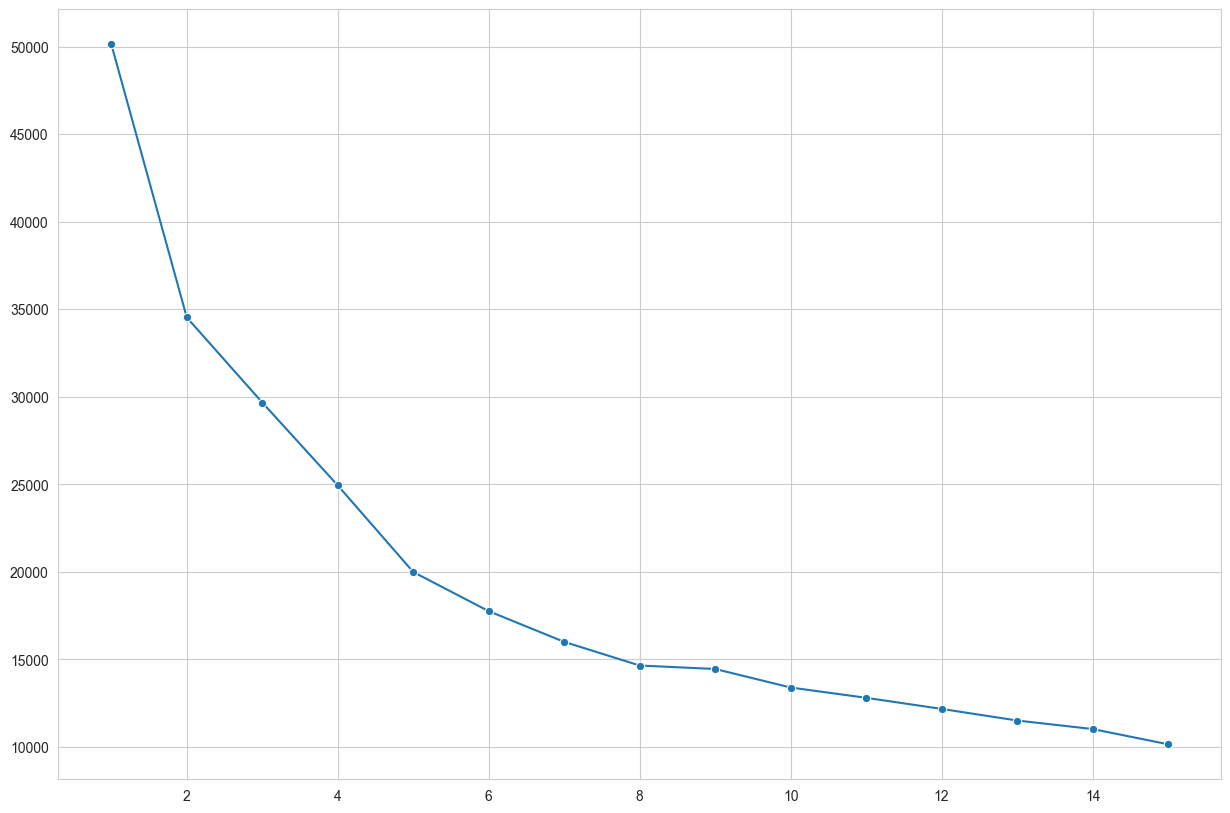

In [27]:
# 클러스터링에 사용할 feature 선정 (수치형 데이터)
feature_data = groupby_merge_df.select_dtypes(['int', 'float'])

# 표준화
scaler = StandardScaler()
feature_data_scaled = scaler.fit_transform(feature_data)

# Elbow Method를 통한 적절한 k개 분석
inertia_list = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(feature_data_scaled)
    inertia = kmeans.inertia_
    
    inertia_list.append(inertia)
    
# 계산을 용이하게 하기 위한 numpy 배열 변환
inertia_arr = np.array(inertia_list)    

# Elbow Method 시각화
plt.figure(figsize=(15, 10))
sns.lineplot(x=range(1, 16), y=inertia_list, marker='o')
plt.axvline(x=kl.knee, color='red', linestyle='--', label=f"Optimal k = {kl.knee}")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.legend()
plt.show()

# k를 5개로 두고 클러스터링 진행
kmeans = KMeans(n_clusters=5, random_state=42)
groupby_merge_df['cluster'] = kmeans.fit_predict(feature_data_scaled)

# PCA를 통한 2D 그래프 시각화
pca = PCA(n_components=2)
pca_df = pd.DataFrame(pca.fit_transform(feature_data_scaled), columns=['PCA1', 'PCA2'])
pca_df['cluster'] = groupby_merge_df['cluster']

# 데이터 확인
display(pca_df)

# 시각화 구간간
plt.figure(figsize=(15, 10))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='cluster', palette='muted')
plt.title('Clustering using PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.tight_layout()
plt.show()

# PCA 구성 요소 확인
pca_components = pd.DataFrame(
    pca.components_,  # PCA 구성 요소
    columns=feature_data.columns,  # 원래 feature 이름들
    index=['PCA1', 'PCA2']  # 주성분 이름
)

display(pca_components.T.sort_values(by='PCA1', ascending=False))  # PCA1에 영향을 많이 준 변수 순 정렬
display(pca_components.T.sort_values(by='PCA2', ascending=False))  # PCA2에 영향을 많이 준 변수 순 정렬

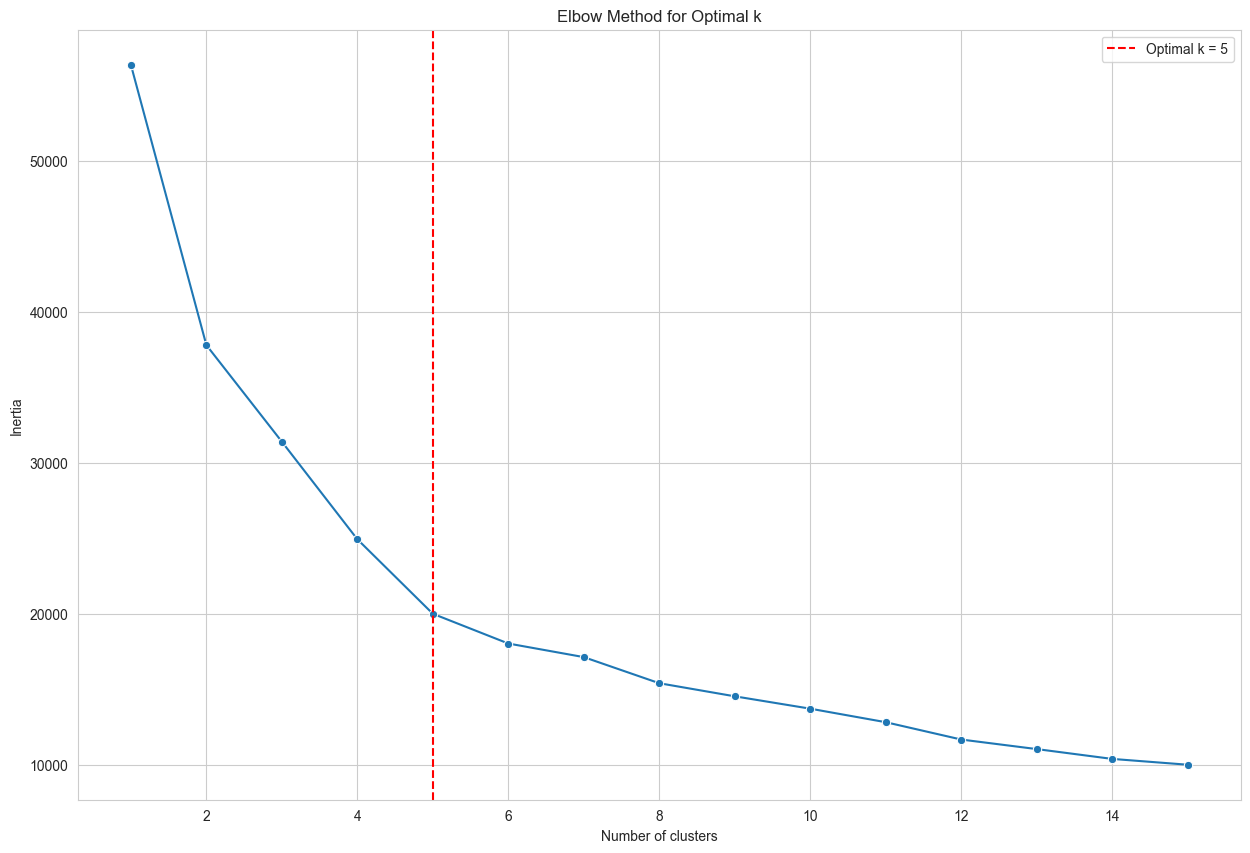

,PCA1,PCA2,cluster
0,-0.846491,-0.529085,0
1,1.821481,0.089555,2
2,2.407448,-0.827800,2
3,-1.052009,0.180897,0
4,0.900367,-0.553537,2
...,...,...,...
6261,0.546322,-1.239669,2
6262,-0.583508,0.206953,0
6263,-1.755005,-0.384949,0
6264,2.265222,0.090611,2


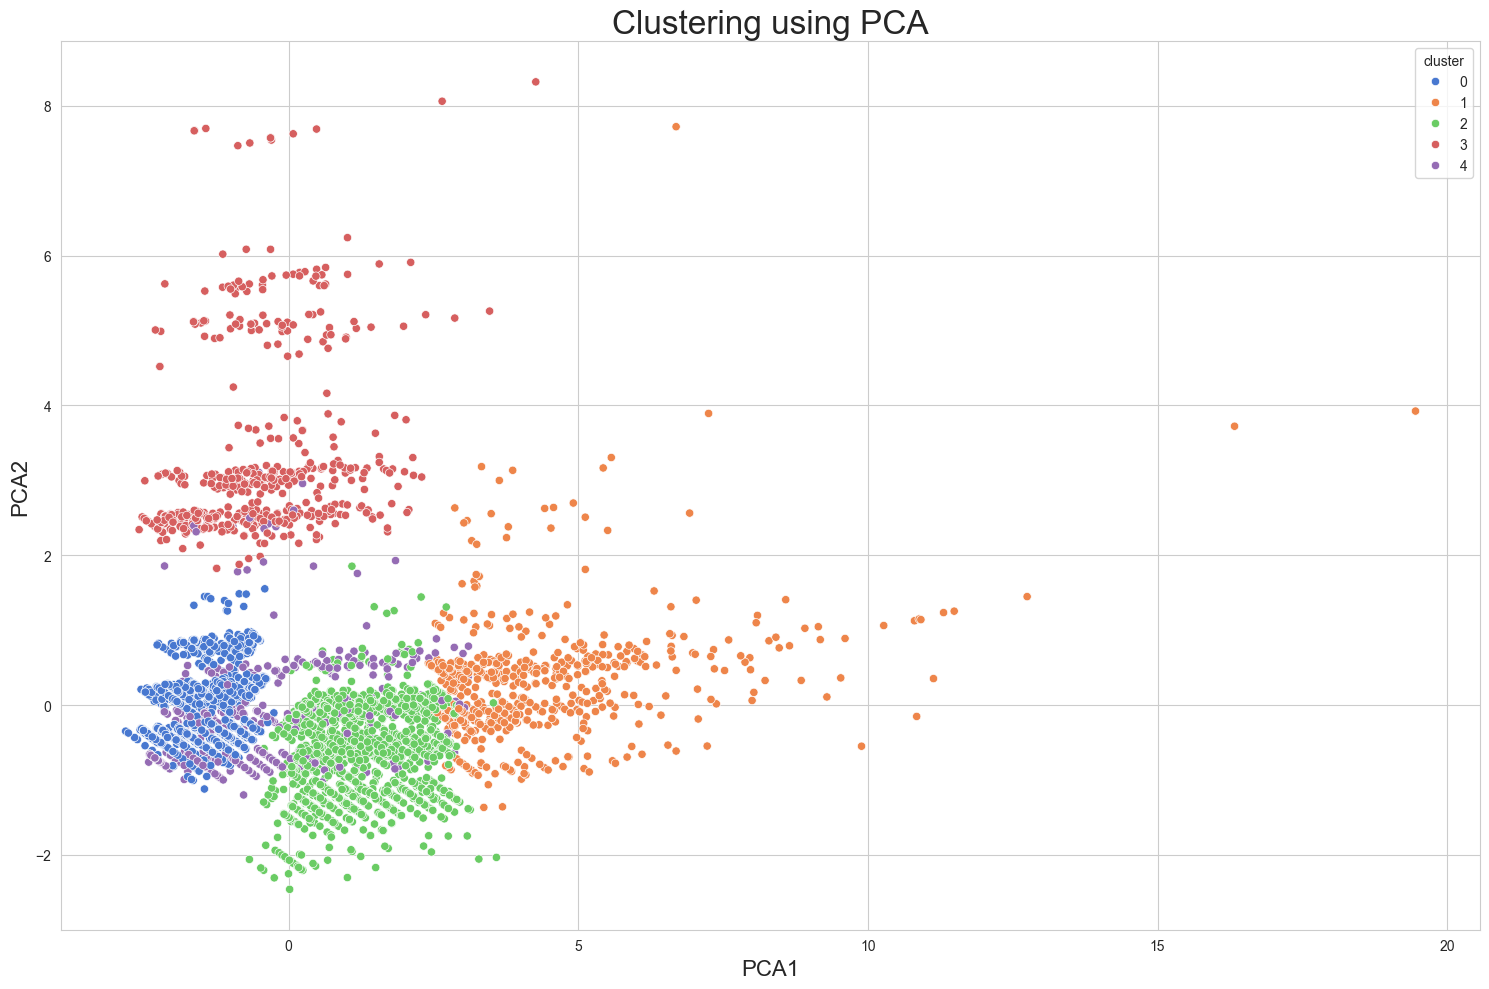

,PCA1,PCA2
weekday,0.453113,0.067756
hour,0.453113,0.067756
avg_checkout_count,0.436468,0.023832
avg_checkin_count,0.435404,0.030531
avg_stay_time_second,0.274716,-0.156338
visit_count,0.193084,0.515927
site_id,-0.018165,-0.014758
office_count,-0.018340,0.725001
cluster,-0.309646,0.415755


,PCA1,PCA2
office_count,-0.018340,0.725001
visit_count,0.193084,0.515927
cluster,-0.309646,0.415755
weekday,0.453113,0.067756
hour,0.453113,0.067756
avg_checkin_count,0.435404,0.030531
avg_checkout_count,0.436468,0.023832
site_id,-0.018165,-0.014758
avg_stay_time_second,0.274716,-0.156338


In [ ]:
# site_id를 정리한 데이터
feature_data_filtered = groupby_merge_df.select_dtypes(['int', 'float']).drop(labels='site_id', axis=1)

# 표준화
scaler = StandardScaler()
feature_data_scaled = scaler.fit_transform(feature_data)

# Elbow Method를 통한 적절한 k개 분석
inertia_list = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(feature_data_scaled)
    inertia = kmeans.inertia_
    
    inertia_list.append(inertia)
    
# 계산을 용이하게 하기 위한 numpy 배열 변환
inertia_arr = np.array(inertia_list)    

# Elbow Method 시각화
plt.figure(figsize=(15, 10))
sns.lineplot(x=range(1, 16), y=inertia_list, marker='o')
plt.axvline(x=kl.knee, color='red', linestyle='--', label=f"Optimal k = {kl.knee}")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.legend()
plt.show()

# k를 5개로 두고 클러스터링 진행
kmeans = KMeans(n_clusters=5, random_state=42)
groupby_merge_df['cluster'] = kmeans.fit_predict(feature_data_scaled)

# PCA를 통한 2D 그래프 시각화
pca = PCA(n_components=2)
pca_df = pd.DataFrame(pca.fit_transform(feature_data_scaled), columns=['PCA1', 'PCA2'])
pca_df['cluster'] = groupby_merge_df['cluster']

# 데이터 확인
display(pca_df)

# 시각화 구간
plt.figure(figsize=(15, 10))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='cluster', palette='muted')
plt.title('Clustering using PCA', fontsize=24)
plt.xlabel('PCA1', fontsize=16)
plt.ylabel('PCA2', fontsize=16)
plt.tight_layout()
plt.show()

# PCA 구성 요소 확인
pca_components = pd.DataFrame(
    pca.components_,  # PCA 구성 요소
    columns=feature_data.columns,  # 원래 feature 이름들
    index=['PCA1', 'PCA2']  # 주성분 이름
)

display(pca_components.T.sort_values(by='PCA1', ascending=False))  # PCA1에 영향을 많이 준 변수 순 정렬
display(pca_components.T.sort_values(by='PCA2', ascending=False))  # PCA2에 영향을 많이 준 변수 순 정렬

In [28]:
for df in df_lst:
    display(df)

,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0
...,...,...
9654,2023-11-17,d7599df4-1e5a-4f5e-97ce-c42047bfd87c
9655,2023-11-17,43263092-3b28-4817-9fa9-4205ad3097fe
9656,2023-11-17,51a40f33-1027-4544-9b95-45bca7c104fb
9657,2023-11-18,3e649531-bf5b-4b99-84e5-ca3e0e647d0c


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594
...,...,...,...,...,...,...,...
11472,6,2022-06-16,06:47:59.975925,24479,2022-06-16 11:00:48.643935,2022-06-16 18:23:38.495290,766221e7-a753-444f-aa5a-ae76ce86d3fd
11473,6,2022-06-17,01:28:46.221537,5326,2022-06-17 17:15:05.221223,2022-06-17 18:56:00.840639,0a70277f-a7f9-401c-95fa-ed6d96ee32e0
11474,6,2022-06-16,05:08:03.166662,18483,2022-06-16 12:52:46.557742,2022-06-16 18:23:34.355309,0a70277f-a7f9-401c-95fa-ed6d96ee32e0
11475,6,2023-02-06,06:30:29.693768,23429,2023-02-06 10:14:00.538281,2023-02-06 16:52:37.606175,576473bb-0647-483e-b06a-a5ff6491b08b


,id,checkin,cdate,site_id,user_uuid,cdate_period
0,1719038,1,2023-07-07 16:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,2023-07-07
1,1716702,2,2023-07-07 00:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,2023-07-07
2,1719956,2,2023-07-07 23:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,2023-07-07
3,1716588,1,2023-07-06 22:09:48.758097,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,2023-07-06
4,1719649,1,2023-07-07 19:12:42.083352,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,2023-07-07
...,...,...,...,...,...,...
63703,1525518,2,2023-04-26 18:04:44.770319,49,8b271f57-2ce2-4b32-80b8-0fabb98390a7,2023-04-26
63704,1524555,1,2023-04-26 15:09:14.228682,49,8b271f57-2ce2-4b32-80b8-0fabb98390a7,2023-04-26
63705,2043662,1,2023-11-04 20:50:10.657353,49,c02b96c8-bcba-4f8c-baf8-99f6c35076f4,2023-11-04
63706,2043791,2,2023-11-04 22:31:41.599473,49,c02b96c8-bcba-4f8c-baf8-99f6c35076f4,2023-11-04


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3
3,0,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,0,1d49ba36-6c23-405b-9514-aa7f4aeceff0
...,...,...
9654,0,d7599df4-1e5a-4f5e-97ce-c42047bfd87c
9655,0,43263092-3b28-4817-9fa9-4205ad3097fe
9656,0,51a40f33-1027-4544-9b95-45bca7c104fb
9657,0,3e649531-bf5b-4b99-84e5-ca3e0e647d0c


,site_id,area_pyeong
0,1,50
1,2,100
2,3,150
3,4,100
4,5,150
5,6,150
6,17,50
7,47,50
8,49,50


## 지도 학습

지도 학습을 위한 독립변수 지정
> 기준 : user_uuid
> 1. 해당 유저의 평균 체류 시간
> 2. 해당 유저의 총 방문 횟수
> 3. 해당 유저의 출입한 총 횟수 (access_log 기준)
> 4. 해당 유저의 퇴장한 총 횟수 (access_log 기준)
> 5. 해당 유저가 자주 사용한 시간대 (오전/오후/저녁/야간, visit_info의 first_enter_time 기준)
> 6. 해당 유저가 방문 횟수에 따른 이용한 공유 오피스<br/>
> └ 이 내용의 경우 Day 1, Day 2, Day 3를 적용하여 각 사용한 지점의 site_id 값 등록
> 7. 해당 유저가 방문 횟수에 따른 사용한 공유 오피스의 평수<br/>
> └ 이 내용의 경우 Day 1, Day 2, Day 3를 적용하여 각 사용한 지점의 site_id의 평수 등록
> 종속변수 : 해당 유저의 결제 여부

In [ ]:
# 지도학습에 선정한 독립변수 데이터 만들기
# 해당 유저의 평균 체류 시간
average_stay_time_second = trial_visit_info.groupby('user_uuid')['stay_time_second'].mean().reset_index()
display('평균 체류 시간', average_stay_time_second)

# 해당 유저의 총 방문 횟수
total_visit_count = trial_visit_info.groupby('user_uuid')['first_enter_time'].size().reset_index()
display('총 방문 횟수', total_visit_count)

# 해당 유저의 출입한 총 횟수
total_access_checkin_count = trial_access_log.groupby('user_uuid').agg(
    total_checkin_count = ('checkin', lambda x: (x == 1).sum())
).reset_index()
display('access_log 기준 총 출입 횟수', total_access_checkin_count)

# 해당 유저의 퇴장한 총 횟수
total_access_checkout_count = trial_access_log.groupby('user_uuid').agg(
    total_checkout_count = ('checkin', lambda x: (x == 2).sum())
).reset_index()
display('access_log 기준 총 퇴장 횟수', total_access_checkout_count)

# 해당 유저가 자주 사용한 시간대
most_time_user_used = trial_visit_info.groupby('user_uuid').agg(
    most_time_average = ('first_enter_time', lambda x: (pd.to_datetime(x, format='mixed').dt.hour).mean())
).reset_index()
display('해당 유저가 자주 사용한 시간대', most_time_user_used)

# 해당 유저가 방문 횟수에 따른 이용한 공유 오피스
used_site = trial_visit_info.groupby('user_uuid')['site_id'].agg(list).reset_index()
used_site['day1_site'] = used_site['site_id'].apply(lambda x: x[0])
used_site['day2_site'] = used_site['site_id'].apply(lambda x: x[1] if len(x) > 1 else 0)
used_site['day3_site'] = used_site['site_id'].apply(lambda x: x[2] if len(x) > 2 else 0)
if 'site_id' in used_site.columns:
    used_site.drop(labels='site_id', axis=1, inplace=True)
display('해당 유저가 이용한 공유 오피스', used_site)

# 해당 유저가 방문 횟수에 따른 이용한 공유 오피스의 평수
used_site_area = trial_visit_info.groupby('user_uuid')['site_id'].agg(list).reset_index()
used_site_area['day1_site_area'] = used_site['day1_site'].apply(
    lambda x: site_area[site_area['site_id'] == x]['area_pyeong'].values[0] if not site_area[site_area['site_id'] == x].empty else 0
)
used_site_area['day2_site_area'] = used_site['day2_site'].apply(
    lambda x: site_area[site_area['site_id'] == x]['area_pyeong'].values[0] if not site_area[site_area['site_id'] == x].empty else 0
)
used_site_area['day3_site_area'] = used_site['day3_site'].apply(
    lambda x: site_area[site_area['site_id'] == x]['area_pyeong'].values[0] if not site_area[site_area['site_id'] == x].empty else 0
)
if 'site_id' in used_site_area.columns:
    used_site_area.drop(labels='site_id', axis=1, inplace=True)
display('해당 유저가 이용한 공유 오피스의 평수', used_site_area)

'평균 체류 시간'

,user_uuid,stay_time_second
0,000590dc-046f-462b-8225-4c81a97b7166,21417.000000
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,15189.666667
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,38686.000000
3,002606d9-38ca-48f3-910c-cbfada9a9109,12512.000000
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,11804.500000
...,...,...
6529,ffc79669-ed11-4cde-86d4-8ec232ac7b14,17292.500000
6530,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,14806.500000
6531,ffce32ca-2efc-4485-b685-4b65811c2dcf,8450.000000
6532,ffd287bc-2797-4788-82fa-6268c82e7fa9,17618.333333


'총 방문 횟수'

,user_uuid,first_enter_time
0,000590dc-046f-462b-8225-4c81a97b7166,1
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,3
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,2
3,002606d9-38ca-48f3-910c-cbfada9a9109,2
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,2
...,...,...
6529,ffc79669-ed11-4cde-86d4-8ec232ac7b14,2
6530,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,2
6531,ffce32ca-2efc-4485-b685-4b65811c2dcf,1
6532,ffd287bc-2797-4788-82fa-6268c82e7fa9,3


'access_log 기준 총 출입 횟수'

...

,user_uuid,most_time_average
0,000590dc-046f-462b-8225-4c81a97b7166,11.0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,16.0
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,9.0
3,002606d9-38ca-48f3-910c-cbfada9a9109,16.0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,16.5
...,...,...
6529,ffc79669-ed11-4cde-86d4-8ec232ac7b14,18.0
6530,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,13.5
6531,ffce32ca-2efc-4485-b685-4b65811c2dcf,0.0
6532,ffd287bc-2797-4788-82fa-6268c82e7fa9,15.0


'해당 유저가 이용한 공유 오피스'

,user_uuid,day1_site,day2_site,day3_site
0,000590dc-046f-462b-8225-4c81a97b7166,6,0,0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,3,3,3
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,6,6,0
3,002606d9-38ca-48f3-910c-cbfada9a9109,17,17,0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,5,5,0
...,...,...,...,...
6529,ffc79669-ed11-4cde-86d4-8ec232ac7b14,1,1,0
6530,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,2,2,0
6531,ffce32ca-2efc-4485-b685-4b65811c2dcf,4,0,0
6532,ffd287bc-2797-4788-82fa-6268c82e7fa9,6,6,6


'해당 유저가 이용한 공유 오피스의 평수'

,user_uuid,day1_site_area,day2_site_area,day3_site_area
0,000590dc-046f-462b-8225-4c81a97b7166,150,0,0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,150,150,150
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,150,150,0
3,002606d9-38ca-48f3-910c-cbfada9a9109,50,50,0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,150,150,0
...,...,...,...,...
6529,ffc79669-ed11-4cde-86d4-8ec232ac7b14,50,50,0
6530,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,100,100,0
6531,ffce32ca-2efc-4485-b685-4b65811c2dcf,100,0,0
6532,ffd287bc-2797-4788-82fa-6268c82e7fa9,150,150,150


In [58]:
# 데이터 전체 merge
dfs = [average_stay_time_second,
       total_visit_count,
       total_access_checkin_count,
       total_access_checkout_count,
       most_time_user_used,
       used_site,
       used_site_area]
total_dataframe = reduce(lambda left, right: pd.merge(left, right, on='user_uuid'), dfs)

# 데이터 확인
display(total_dataframe)

# 데이터 종속 변수 merge
total_dataframe = total_dataframe.merge(
    trial_payment,
    how='inner',
    on='user_uuid'
)

# 데이터 확인
display(total_dataframe)

,user_uuid,stay_time_second,first_enter_time,total_checkin_count,total_checkout_count,most_time_average,day1_site,day2_site,day3_site,day1_site_area,day2_site_area,day3_site_area
0,000590dc-046f-462b-8225-4c81a97b7166,21417.000000,1,3,3,11.0,6,0,0,150,0,0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,15189.666667,3,9,9,16.0,3,3,3,150,150,150
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,38686.000000,2,11,8,9.0,6,6,0,150,150,0
3,002606d9-38ca-48f3-910c-cbfada9a9109,12512.000000,2,4,4,16.0,17,17,0,50,50,0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,11804.500000,2,5,5,16.5,5,5,0,150,150,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6018,ffc79669-ed11-4cde-86d4-8ec232ac7b14,17292.500000,2,5,4,18.0,1,1,0,50,50,0
6019,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,14806.500000,2,5,5,13.5,2,2,0,100,100,0
6020,ffce32ca-2efc-4485-b685-4b65811c2dcf,8450.000000,1,2,2,0.0,4,0,0,100,0,0
6021,ffd287bc-2797-4788-82fa-6268c82e7fa9,17618.333333,3,10,10,15.0,6,6,6,150,150,150


,user_uuid,stay_time_second,first_enter_time,total_checkin_count,total_checkout_count,most_time_average,day1_site,day2_site,day3_site,day1_site_area,day2_site_area,day3_site_area,is_payment
0,000590dc-046f-462b-8225-4c81a97b7166,21417.000000,1,3,3,11.0,6,0,0,150,0,0,0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,15189.666667,3,9,9,16.0,3,3,3,150,150,150,1
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,38686.000000,2,11,8,9.0,6,6,0,150,150,0,0
3,002606d9-38ca-48f3-910c-cbfada9a9109,12512.000000,2,4,4,16.0,17,17,0,50,50,0,0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,11804.500000,2,5,5,16.5,5,5,0,150,150,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6043,ffc79669-ed11-4cde-86d4-8ec232ac7b14,17292.500000,2,5,4,18.0,1,1,0,50,50,0,0
6044,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,14806.500000,2,5,5,13.5,2,2,0,100,100,0,0
6045,ffce32ca-2efc-4485-b685-4b65811c2dcf,8450.000000,1,2,2,0.0,4,0,0,100,0,0,0
6046,ffd287bc-2797-4788-82fa-6268c82e7fa9,17618.333333,3,10,10,15.0,6,6,6,150,150,150,0


In [71]:
# feature, target 변수 지정
total_dataframe_numeric = total_dataframe.select_dtypes(['int', 'float'])
X = total_dataframe_numeric.drop(labels='is_payment', axis=1)
y = total_dataframe_numeric['is_payment']

# 각각 데이터를 train set과 test set 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# LightGBM은 데이터행의 개수가 1만행보다 많지 않으므로 제외, CatBoost와 XGBoost로 진행

### CatBoostClassifier

In [80]:
# 모델 정의
# 종속 변수에 클래스 불균형이 있기에 처음 불러올 때 불균형에 대응하기 위한 옵션 불러오기
cat_model = CatBoostClassifier(
    auto_class_weights='Balanced', # 클래스 불균형 대응
    verbose=0,
    random_state=42
)

# 파라미터 정리
param_grid = {
    'depth' : [4, 6, 8],
    'learning_rate' : [0.01, 0.05, 0.1, 0.3, 0.5],
    'iterations' : [100, 300, 500]
}

# StratifiedKFold를 통한 교차 검증 (불균형 대응
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV 실행
search_cat = RandomizedSearchCV(estimator=cat_model, param_distributions=param_grid,
                                n_iter=10, scoring='f1', cv=cv, n_jobs=-1, random_state=42, verbose=1)

# 모델 훈련
search_cat.fit(X_train, y_train)

# 학습 데이터에 대한 성능 평가
y_train_pred = search_cat.predict(X_train)
print('Train set performance:')
print(classification_report(y_train, y_train_pred))

# 예측 및 평가
y_pred = search_cat.predict(X_test)
print('Test set performance')
print(classification_report(y_test, y_pred))

# 모델의 베스트파라미터 출력
print(f'Best Param : {search_cat.best_params_}\n')

# 과적합 정도 계산
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_pred)
overfitting_ratio = train_f1 / test_f1 if test_f1 > 0 else float('inf')

print(f'Train F1 score: {train_f1:.4f}')
print(f'Test F1 score: {test_f1:.4f}\n')
print(f'Overfitting ratio (Train F1 / Test F1): {overfitting_ratio:.4f}')
print(f'Performance gap (Train F1 - Test F1): {train_f1 - test_f1:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Train set performance:
              precision    recall  f1-score   support

           0       0.74      0.73      0.74      2599
           1       0.58      0.60      0.59      1634

    accuracy                           0.68      4233
   macro avg       0.66      0.66      0.66      4233
weighted avg       0.68      0.68      0.68      4233

Test set performance
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      1104
           1       0.52      0.52      0.52       711

    accuracy                           0.62      1815
   macro avg       0.60      0.60      0.60      1815
weighted avg       0.62      0.62      0.62      1815

Best Param : {'learning_rate': 0.01, 'iterations': 300, 'depth': 8}

Train F1 score: 0.5898
Test F1 score: 0.5200

Overfitting ratio (Train F1 / Test F1): 1.1343
Performance gap (Train F1 - Test F1): 0.0698


### XGBoostClassifier

In [82]:
# 모델 정의
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 종속변수에 클래스 불균형이 존재하여 클래스 비율 계산
neg, pos = np.bincount(y_train)
scale_weight = neg / pos

# 파라미터 그리드
param_grid = {
    'max_depth' : [4, 6, 8],
    'learning_rate' : [0.01, 0.05, 0.1, 0.5, 1],
    'n_estimators': [100, 300, 500],
    'scale_pos_weight' : [scale_weight]
}

# StratifiedFold를 통한 교차검증 (불균형 대응)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV 실행
search_xgb = RandomizedSearchCV(xgb_model, param_distributions=param_grid,
                                n_iter=10, scoring='f1', cv=cv, n_jobs=-1,
                                random_state=42, verbose=1)

# 모델 훈련
search_xgb.fit(X_train, y_train)

# 학습 데이터에 대한 성능 평가
y_train_pred = search_xgb.predict(X_train)
print('Train set performance:')
print(classification_report(y_train, y_train_pred))

# 예측 및 평가
y_pred = search_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

# 모델의 베스트파라미터 출력
print(f'Best Param : {search_xgb.best_params_}\n')

# 과적합 정도 계산
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_pred)
overfitting_ratio = train_f1 / test_f1 if test_f1 > 0 else float('inf')

print(f'Train F1 score: {train_f1:.4f}')
print(f'Test F1 score: {test_f1:.4f}\n')
print(f'Overfitting ratio (Train F1 / Test F1): {overfitting_ratio:.4f}')
print(f'Performance gap (Train F1 - Test F1): {train_f1 - test_f1:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Train set performance:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      2599
           1       0.57      0.57      0.57      1634

    accuracy                           0.67      4233
   macro avg       0.65      0.65      0.65      4233
weighted avg       0.67      0.67      0.67      4233

              precision    recall  f1-score   support

           0       0.67      0.67      0.67      1104
           1       0.49      0.49      0.49       711

    accuracy                           0.60      1815
   macro avg       0.58      0.58      0.58      1815
weighted avg       0.60      0.60      0.60      1815

Best Param : {'scale_pos_weight': np.float64(1.5905752753977969), 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.01}

Train F1 score: 0.5716
Test F1 score: 0.4919

Overfitting ratio (Train F1 / Test F1): 1.1620
Performance gap (Train F1 - Test F1): 0.07

전체적인 내용을 모아 분석을 하였을 때 다음과 같다.

정확도(Accuracy) 지표
- CatBoost: 훈련 68%, 테스트 62%
- XGBoost: 훈련 67%, 테스트 60%

F1 점수(클래스 1 기준)
- CatBoost: 훈련 0.5898, 테스트 0.5200
- XGBoost: 훈련 0.5716, 테스트 0.4919

과적합 지표
- CatBoost: 과적합 비율 1.1343, 성능 격차 0.0698
- XGBoost: 과적합 비율 1.1620, 성능 격차 0.0797

분석
1. 성능 우위: CatBoost가 모든 지표에서 XGBoost보다 우수한 성능을 보인다. 테스트 세트에서 F1 점수가 0.52 vs 0.49로 CatBoost가 더 높다.
2. 과적합 정도 : 두 모델 모두 약간의 과적합이 있지만, CatBoost가 상대적으로 더 안정적.
3. 클래스 불균형 처리 : 두 모델 모두 클래스 0(다수 클래스)에서 클래스 1(소수 클래스) 보다 더 나은 성능을 보인다.

결론

CatBoost를 사용하는 것이 더 나은 선택

### 베스트 모델에 따른 변수 중요도 출력

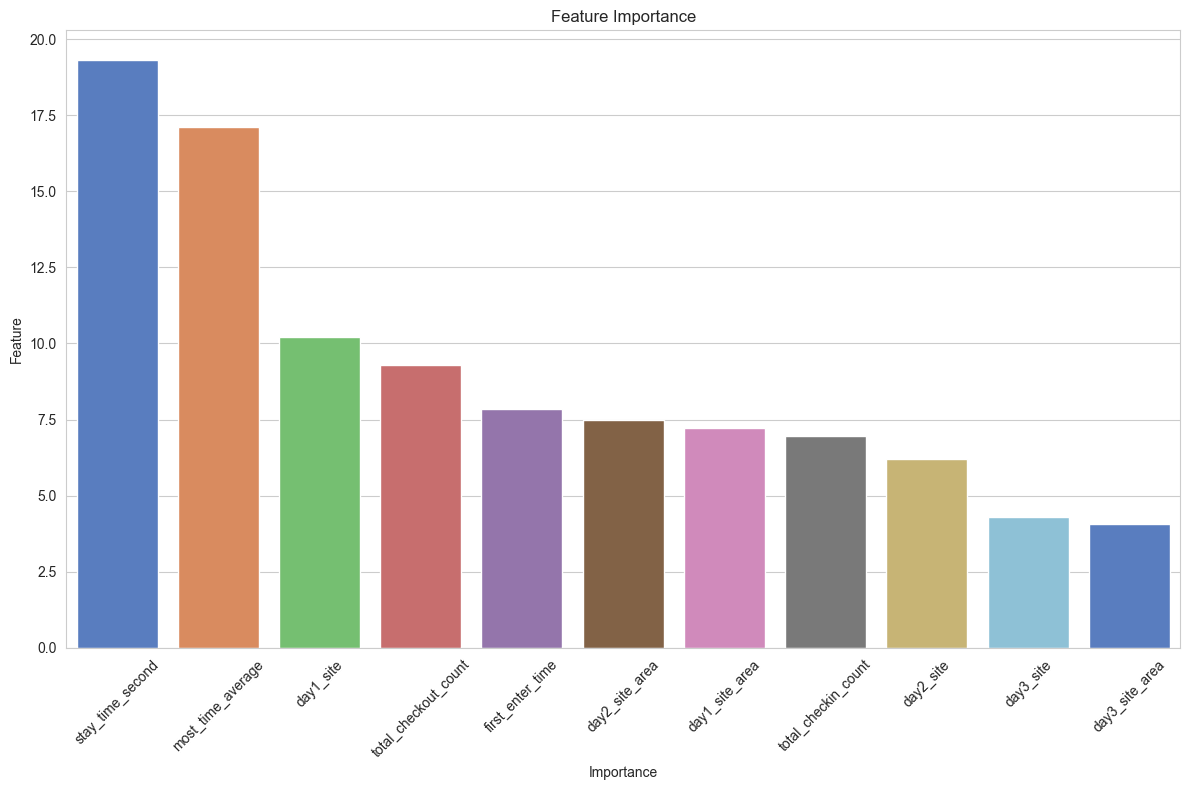

,Feature,Importance
0,stay_time_second,19.318566
4,most_time_average,17.119030
5,day1_site,10.206925
3,total_checkout_count,9.280472
1,first_enter_time,7.844476
9,day2_site_area,7.471467
8,day1_site_area,7.216106
2,total_checkin_count,6.968892
6,day2_site,6.211516
7,day3_site,4.288179


In [ ]:
# 최적 모델 가져오기
best_model = search_cat.best_estimator_

# 특성 중요도 추출
feature_importance = best_model.get_feature_importance()

# 특성 이름 가져오기 (X_train의 컬럼명이 있다고 가정)
feature_names = X_train.columns

# 중요도와 특성 이름을 함께 데이터프레임으로 만들기
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# 중요도에 따라 내림차순 정렬
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Feature', y='Importance', hue='Feature', palette='muted', legend=False)
plt.xticks(rotation=45)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# 특성 중요도 출력
display(importance_df)